# UNSW-NB15 — Task 2 Baselines
Group 5 · CSE475 · Track 1 (GNN)

Target: `attack_cat` (multiclass — Normal + 9 attack categories), matching the GNN's eventual
per-flow/host comparison. Trains 5 models on `train_processed`, evaluates on `test_processed`,
ranks by macro-F1 (not accuracy — the class imbalance makes accuracy misleading, see Task 1 EDA).

**Practical note on SVM:** a standard kernel SVC does not scale to ~1.6M rows (training time is
roughly cubic in sample count). This notebook uses `LinearSVC` instead, calibrated for probability
estimates on a stratified subsample — this substitution should be stated explicitly in the report.

In [1]:
import os, time, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (precision_recall_fscore_support, confusion_matrix, accuracy_score,
                              roc_auc_score, average_precision_score, classification_report,
                              precision_recall_curve)
import xgboost as xgb

SEED = 42
np.random.seed(SEED)

## CONFIG — edit paths to match your setup

In [2]:
CFG = {
    'prep_dir': '/kaggle/input/datasets/humairahabibusha/unsw-nb15-preprocessed-dataset',  # EDIT — your preprocessing output folder
    'target_col': 'attack_cat',
    'flow_id_col': 'flow_id',
    'svm_calibration_subsample': 200_000,   # rows used for LinearSVC + CalibratedClassifierCV
    'out_dir': '/kaggle/working/task2_baseline_outputs',
}
os.makedirs(CFG['out_dir'], exist_ok=True)

## 1. Load preprocessed data

In [3]:
def load_pkl(folder, name):
    with open(os.path.join(folder, f'{name}.pkl'), 'rb') as f:
        return pickle.load(f)

train_df = load_pkl(CFG['prep_dir'], 'train_processed')
test_df = load_pkl(CFG['prep_dir'], 'test_processed')
fitted_transforms = load_pkl(CFG['prep_dir'], 'fitted_transforms')

print("train:", train_df.shape, " test:", test_df.shape)
print(train_df.columns.tolist())

train: (1647532, 32)  test: (411883, 32)
['proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'service', 'Sload', 'Dload', 'Spkts', 'swin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'Sjit', 'Djit', 'Sintpkt', 'Dintpkt', 'tcprtt', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_src_ltm', 'ct_dst_sport_ltm', 'attack_cat', 'Label', 'flow_id']


## 2. Build X / y — drop flow_id and Label, keep attack_cat as target

In [4]:
drop_cols = [CFG['flow_id_col'], CFG['target_col']]
if 'Label' in train_df.columns:
    drop_cols.append('Label')   # binary label — not the target here, would leak the answer

X_train = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
X_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])

le = LabelEncoder()
y_train = le.fit_transform(train_df[CFG['target_col']])   # fit on TRAIN only
y_test = le.transform(test_df[CFG['target_col']])         # transform test with train's encoder

print("Classes:", list(le.classes_))
print("X_train:", X_train.shape, " X_test:", X_test.shape)

Classes: ['Analysis', 'Backdoors', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']
X_train: (1647532, 29)  X_test: (411883, 29)


## 3. Class weights — from your fitted_transforms (train-only, already computed)

In [5]:
raw_weights = fitted_transforms['attack_cat_class_weights']
class_weight_dict = {le.transform([k])[0]: v**0.5 for k, v in raw_weights.items() if k in le.classes_}

sample_weight_train = np.array([class_weight_dict[y] for y in y_train])
print("Class weight dict (encoded label -> weight):", class_weight_dict)

Class weight dict (encoded label -> weight): {np.int64(0): np.float64(10.525953450033862), np.int64(1): np.float64(11.288017313953931), np.int64(2): np.float64(6.535700011743602), np.int64(3): np.float64(2.9793137705876083), np.int64(4): np.float64(3.325692549602121), np.int64(5): np.float64(3.201211905861788), np.int64(6): np.float64(0.32278215682333294), np.int64(7): np.float64(4.295998904417838), np.int64(8): np.float64(12.727891159680173), np.int64(9): np.float64(37.85018522727637)}


## 4. Evaluation helper

In [6]:
def evaluate(name, y_true, y_pred, y_proba, classes, train_time):
    acc = accuracy_score(y_true, y_pred)
    precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0)
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=classes, columns=classes)

    y_true_bin = label_binarize(y_true, classes=range(len(classes)))
    try:
        roc_auc = roc_auc_score(y_true_bin, y_proba, average='macro', multi_class='ovr')
    except ValueError:
        roc_auc = float('nan')
    try:
        pr_auc = average_precision_score(y_true_bin, y_proba, average='macro')
    except ValueError:
        pr_auc = float('nan')

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))
    print("Confusion matrix:")
    print(cm_df)

    return {
        'model': name, 'accuracy': acc,
        'precision_macro': precision_m, 'recall_macro': recall_m, 'f1_macro': f1_m,
        'precision_weighted': precision_w, 'recall_weighted': recall_w, 'f1_weighted': f1_w,
        'roc_auc_macro': roc_auc, 'pr_auc_macro': pr_auc, 'train_time_sec': train_time,
        'confusion_matrix': cm,
    }

results = []
predictions_store = {}
models_store = {}

In [7]:
# ct_ftp_cmd (and possibly others) can hold literal ' ' instead of a number in the raw data —
# not caught by missing-value fill (not NaN) or categorical encoding (not proto/service/state)
for col in X_train.columns:
    if X_train[col].dtype == object:
        X_train[col] = pd.to_numeric(X_train[col].astype(str).str.strip(), errors='coerce').fillna(0)
        X_test[col] = pd.to_numeric(X_test[col].astype(str).str.strip(), errors='coerce').fillna(0)
        print(f"Coerced {col} to numeric")

Coerced ct_ftp_cmd to numeric


## 5. Logistic Regression

In [8]:
t0 = time.time()
lr = LogisticRegression(max_iter=1000, class_weight=class_weight_dict, n_jobs=-1)
lr.fit(X_train, y_train)
train_time = time.time() - t0

y_pred = lr.predict(X_test)
y_proba = lr.predict_proba(X_test)
results.append(evaluate('LogisticRegression', y_test, y_pred, y_proba, le.classes_, train_time))
predictions_store['LogisticRegression'] = {'y_pred': y_pred, 'y_proba': y_proba}
models_store['LogisticRegression'] = lr

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== LogisticRegression ===
Accuracy: 0.9476
                precision    recall  f1-score   support

      Analysis       0.08      0.10      0.09       697
     Backdoors       0.14      0.19      0.16       690
           DoS       0.20      0.03      0.05      1808
      Exploits       0.66      0.69      0.67      9038
       Fuzzers       0.35      0.68      0.46      6899
       Generic       0.91      0.81      0.86      9301
        Normal       1.00      0.97      0.99    378470
Reconnaissance       0.35      0.81      0.49      4430
     Shellcode       0.33      0.15      0.21       494
         Worms       0.09      0.14      0.11        56

      accuracy                           0.95    411883
     macro avg       0.41      0.46      0.41    411883
  weighted avg       0.96      0.95      0.95    411883

Confusion matrix:
                Analysis  Backdoors  DoS  Exploits  Fuzzers  Generic  Normal  \
Analysis              68        127   11       143       32       73  

## 6. Linear SVM (calibrated, subsampled — see note above)

In [9]:
n_sub = min(CFG['svm_calibration_subsample'], len(X_train))
sub_idx, _ = train_test_split(
    np.arange(len(X_train)), train_size=n_sub, stratify=y_train, random_state=SEED)
X_train_sub = X_train.iloc[sub_idx]
y_train_sub = y_train[sub_idx]

t0 = time.time()
svm_base = LinearSVC(class_weight=class_weight_dict, max_iter=5000)
svm = CalibratedClassifierCV(svm_base, cv=3, method='sigmoid')
svm.fit(X_train_sub, y_train_sub)
train_time = time.time() - t0

y_pred = svm.predict(X_test)
y_proba = svm.predict_proba(X_test)
results.append(evaluate('LinearSVM', y_test, y_pred, y_proba, le.classes_, train_time))
predictions_store['LinearSVM'] = {'y_pred': y_pred, 'y_proba': y_proba}
models_store['LinearSVM'] = svm


=== LinearSVM ===
Accuracy: 0.9539
                precision    recall  f1-score   support

      Analysis       0.05      0.00      0.01       697
     Backdoors       0.14      0.00      0.00       690
           DoS       0.15      0.03      0.06      1808
      Exploits       0.66      0.70      0.68      9038
       Fuzzers       0.37      0.46      0.41      6899
       Generic       0.94      0.82      0.88      9301
        Normal       0.99      0.99      0.99    378470
Reconnaissance       0.41      0.63      0.50      4430
     Shellcode       0.00      0.00      0.00       494
         Worms       0.00      0.00      0.00        56

      accuracy                           0.95    411883
     macro avg       0.37      0.36      0.35    411883
  weighted avg       0.95      0.95      0.95    411883

Confusion matrix:
                Analysis  Backdoors  DoS  Exploits  Fuzzers  Generic  Normal  \
Analysis               3          1   51        66       24       12     312   

## 7. Random Forest


=== RandomForest ===
Accuracy: 0.9717
                precision    recall  f1-score   support

      Analysis       0.14      0.51      0.22       697
     Backdoors       0.20      0.38      0.26       690
           DoS       0.65      0.24      0.35      1808
      Exploits       0.83      0.83      0.83      9038
       Fuzzers       0.59      0.53      0.56      6899
       Generic       0.98      0.90      0.94      9301
        Normal       0.99      0.99      0.99    378470
Reconnaissance       0.93      0.80      0.86      4430
     Shellcode       0.48      0.54      0.51       494
         Worms       0.50      0.39      0.44        56

      accuracy                           0.97    411883
     macro avg       0.63      0.61      0.60    411883
  weighted avg       0.97      0.97      0.97    411883

Confusion matrix:
                Analysis  Backdoors  DoS  Exploits  Fuzzers  Generic  Normal  \
Analysis             353        153    6        24        6        0     153

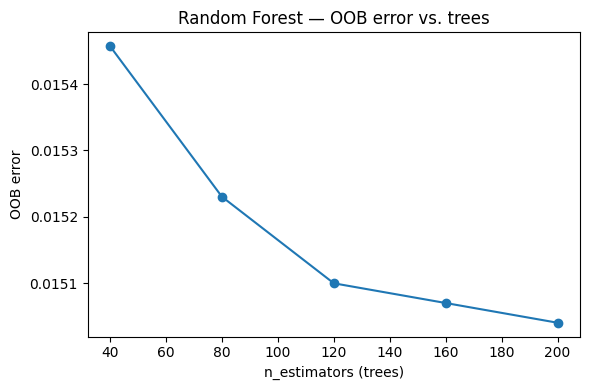

In [10]:
rf_tree_steps = [40, 80, 120, 160, 200]
rf = RandomForestClassifier(
    n_estimators=rf_tree_steps[0], class_weight=class_weight_dict,
    n_jobs=-1, random_state=SEED, warm_start=True, oob_score=True)

t0 = time.time()
rf_oob_curve = []
for n in rf_tree_steps:
    rf.set_params(n_estimators=n)
    rf.fit(X_train, y_train)
    rf_oob_curve.append(1 - rf.oob_score_)
train_time = time.time() - t0

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)
results.append(evaluate('RandomForest', y_test, y_pred, y_proba, le.classes_, train_time))
predictions_store['RandomForest'] = {'y_pred': y_pred, 'y_proba': y_proba}
models_store['RandomForest'] = rf

plt.figure(figsize=(6, 4))
plt.plot(rf_tree_steps, rf_oob_curve, marker='o')
plt.xlabel('n_estimators (trees)'); plt.ylabel('OOB error')
plt.title('Random Forest — OOB error vs. trees')
plt.tight_layout()
plt.savefig(os.path.join(CFG['out_dir'], 'rf_oob_curve.png'), dpi=150)
plt.show()

## 8. XGBoost


=== XGBoost ===
Accuracy: 0.9646
                precision    recall  f1-score   support

      Analysis       0.14      0.56      0.23       697
     Backdoors       0.21      0.33      0.25       690
           DoS       0.48      0.28      0.35      1808
      Exploits       0.77      0.84      0.81      9038
       Fuzzers       0.45      0.81      0.58      6899
       Generic       0.98      0.90      0.94      9301
        Normal       1.00      0.98      0.99    378470
Reconnaissance       0.91      0.80      0.85      4430
     Shellcode       0.40      0.70      0.50       494
         Worms       0.53      0.55      0.54        56

      accuracy                           0.96    411883
     macro avg       0.58      0.68      0.60    411883
  weighted avg       0.98      0.96      0.97    411883

Confusion matrix:
                Analysis  Backdoors  DoS  Exploits  Fuzzers  Generic  Normal  \
Analysis             390        122   28        68        2        1      83   
B

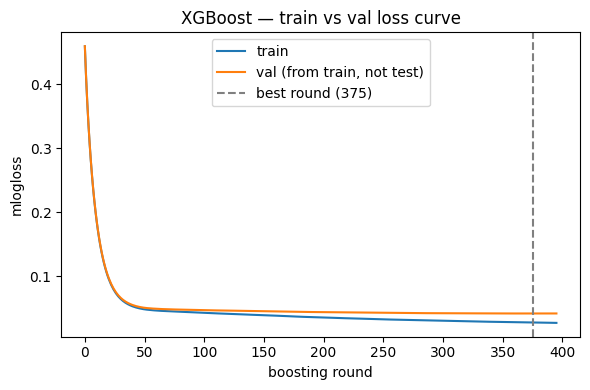

In [11]:
X_tr, X_val, y_tr, y_val, sw_tr, sw_val = train_test_split(
    X_train, y_train, sample_weight_train,
    test_size=0.1, stratify=y_train, random_state=SEED)

t0 = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=8, learning_rate=0.1,
    objective='multi:softprob', num_class=len(le.classes_),
    tree_method='hist', n_jobs=-1, random_state=SEED,
    eval_metric='mlogloss', early_stopping_rounds=20,
)
xgb_model.fit(
    X_tr, y_tr, sample_weight=sw_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False,
)
train_time = time.time() - t0

y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)
results.append(evaluate('XGBoost', y_test, y_pred, y_proba, le.classes_, train_time))
predictions_store['XGBoost'] = {'y_pred': y_pred, 'y_proba': y_proba}
models_store['XGBoost'] = xgb_model

evals_result = xgb_model.evals_result()
plt.figure(figsize=(6, 4))
plt.plot(evals_result['validation_0']['mlogloss'], label='train')
plt.plot(evals_result['validation_1']['mlogloss'], label='val (from train, not test)')
plt.axvline(xgb_model.best_iteration, color='gray', linestyle='--',
            label=f'best round ({xgb_model.best_iteration})')
plt.xlabel('boosting round'); plt.ylabel('mlogloss')
plt.title('XGBoost — train vs val loss curve')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CFG['out_dir'], 'xgb_loss_curve.png'), dpi=150)
plt.show()

## 9. MLP


=== MLP ===
Accuracy: 0.9649
                precision    recall  f1-score   support

      Analysis       0.14      0.04      0.07       697
     Backdoors       0.42      0.04      0.07       690
           DoS       0.40      0.05      0.08      1808
      Exploits       0.65      0.83      0.73      9038
       Fuzzers       0.48      0.55      0.51      6899
       Generic       0.85      0.89      0.87      9301
        Normal       0.99      0.99      0.99    378470
Reconnaissance       0.73      0.68      0.70      4430
     Shellcode       0.40      0.33      0.36       494
         Worms       0.78      0.12      0.22        56

      accuracy                           0.96    411883
     macro avg       0.58      0.45      0.46    411883
  weighted avg       0.96      0.96      0.96    411883

Confusion matrix:
                Analysis  Backdoors  DoS  Exploits  Fuzzers  Generic  Normal  \
Analysis              31          1    7       242       72      161     143   
Backd

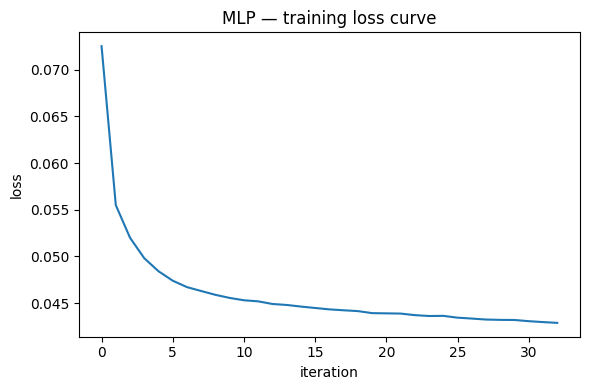

In [12]:
t0 = time.time()
mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                     early_stopping=True, random_state=SEED)
mlp.fit(X_train, y_train)  # no class_weight support — see note below
train_time = time.time() - t0

y_pred = mlp.predict(X_test)
y_proba = mlp.predict_proba(X_test)
results.append(evaluate('MLP', y_test, y_pred, y_proba, le.classes_, train_time))
predictions_store['MLP'] = {'y_pred': y_pred, 'y_proba': y_proba}
models_store['MLP'] = mlp

plt.figure(figsize=(6, 4))
plt.plot(mlp.loss_curve_)
plt.xlabel('iteration'); plt.ylabel('loss')
plt.title('MLP — training loss curve')
plt.tight_layout()
plt.savefig(os.path.join(CFG['out_dir'], 'mlp_loss_curve.png'), dpi=150)
plt.show()

**Note on MLP + class weights:** `sklearn.neural_network.MLPClassifier` doesn't accept
`class_weight` or `sample_weight`. If MLP's recall on rare classes (Worms, Shellcode, Backdoors)
comes out very low, that's expected — flag it as a known MLP limitation in the report rather than
a bug, or switch to a `keras`/`torch` MLP with a weighted loss if you want it to compete fairly.

## 10. Comparison table — pick the baseline to beat

In [13]:
comparison = pd.DataFrame(results).drop(columns=['confusion_matrix'])
comparison = comparison.sort_values('f1_macro', ascending=False).reset_index(drop=True)
print(comparison)

best_model_name = comparison.iloc[0]['model']
print(f"\nBaseline to beat: {best_model_name} (macro-F1 = {comparison.iloc[0]['f1_macro']:.4f})")

                model  accuracy  precision_macro  recall_macro  f1_macro  \
0             XGBoost  0.964594         0.584946      0.676351  0.604234   
1        RandomForest  0.971659         0.628249      0.610452  0.595139   
2                 MLP  0.964876         0.584561      0.451432  0.459728   
3  LogisticRegression  0.947609         0.411432      0.456227  0.408286   
4           LinearSVM  0.953934         0.372307      0.364570  0.352162   

   precision_weighted  recall_weighted  f1_weighted  roc_auc_macro  \
0            0.977081         0.964594     0.969356       0.996140   
1            0.974803         0.971659     0.972469       0.989802   
2            0.963713         0.964876     0.963029       0.993991   
3            0.964484         0.947609     0.953592       0.986823   
4            0.953249         0.953934     0.952821       0.986806   

   pr_auc_macro  train_time_sec  
0      0.628326      490.367014  
1      0.631913      283.231503  
2      0.517214     

In [14]:
comparison.to_csv(os.path.join(CFG['out_dir'], 'baseline_comparison_table.csv'), index=False)

with open(os.path.join(CFG['out_dir'], 'confusion_matrices.pkl'), 'wb') as f:
    pickle.dump({r['model']: r['confusion_matrix'] for r in results}, f)

print("Saved comparison table + confusion matrices to", CFG['out_dir'])

Saved comparison table + confusion matrices to /kaggle/working/task2_baseline_outputs


## 11. Save the best model's predictions + the model object itself

In [15]:
best_preds = predictions_store[best_model_name]
best_model = models_store[best_model_name]

pred_df = pd.DataFrame({
    'flow_id': test_df[CFG['flow_id_col']].values,
    'y_true': y_test,
    'y_pred': best_preds['y_pred'],
})
proba_df = pd.DataFrame(best_preds['y_proba'], columns=[f'prob_{c}' for c in le.classes_])
pred_df = pd.concat([pred_df, proba_df], axis=1)

pred_df.to_csv(os.path.join(CFG['out_dir'], f'{best_model_name}_test_predictions.csv'), index=False)
pred_df.to_pickle(os.path.join(CFG['out_dir'], f'{best_model_name}_test_predictions.pkl'))

with open(os.path.join(CFG['out_dir'], f'{best_model_name}_model.pkl'), 'wb') as f:
    pickle.dump(best_model, f)

with open(os.path.join(CFG['out_dir'], 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(le, f)

print(f"Saved {best_model_name} predictions + model object + label encoder to", CFG['out_dir'])
print("These three files are what Tithi (significance test) and Task 3 (SHAP/LIME) need.")

Saved XGBoost predictions + model object + label encoder to /kaggle/working/task2_baseline_outputs
These three files are what Tithi (significance test) and Task 3 (SHAP/LIME) need.


### PR curves (per class) — for the report

Run this after the comparison table if you want per-class precision-recall curves for the
best model specifically, rather than just the macro PR-AUC number above.

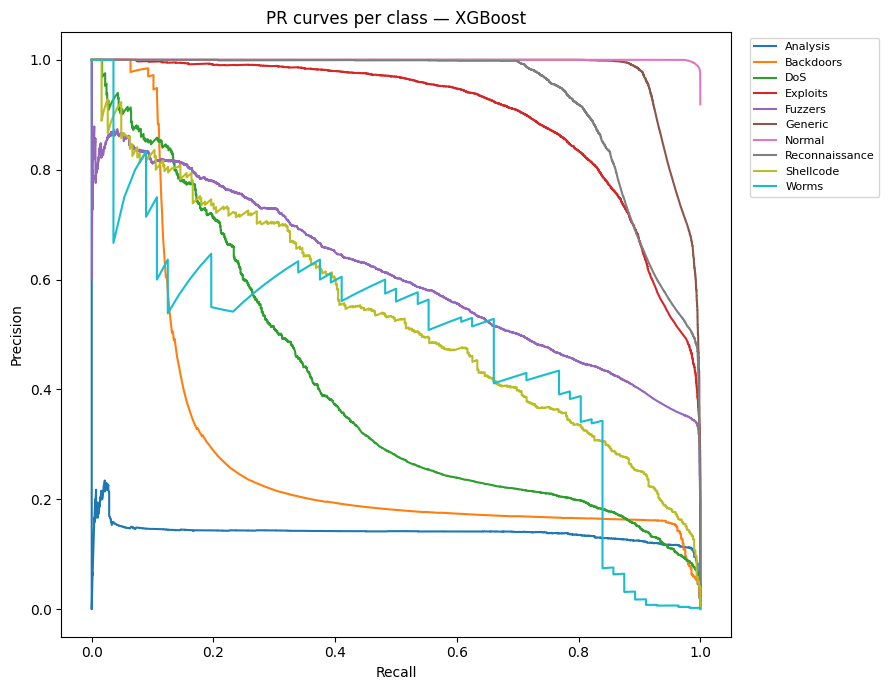

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
best_proba = best_preds['y_proba']

plt.figure(figsize=(9, 7))
for i, cls in enumerate(le.classes_):
    if y_test_bin[:, i].sum() == 0:
        continue
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], best_proba[:, i])
    plt.plot(rec, prec, label=cls)
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title(f'PR curves per class — {best_model_name}')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(CFG['out_dir'], 'pr_curves.png'), dpi=150)
plt.show()